In [1]:
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt
import sympy
from sympy.physics.vector import dynamicsymbols

# Variables

In [2]:
h, kappa, rho, g, i, u, mu, e_b, d_p, A_E, B_E, A, t, t_b, a, lambd, Z_LS, a = sympy.symbols(r"h kappa varrho g i U mu epsilon_b d_p A_E B_E A t t_b alpha lambda Z_LS alpha")
u, e, Z_LS = dynamicsymbols("u epsilon Z_LS")
du = u.diff(t)
ddu = du.diff(t)
nu = mu / rho

constants = {
    rho: 1_000,
    g: 9.81,
    i: 1/1_000,
    mu: 1e-3,
    d_p: 1e-2,
    A_E: 180,
    B_E: 1.75,
    A: 26,
    e_b: 0.1,
    a: 50.,
    t_b: -2,
    lambd: 0.05,
    kappa: 0.41,
    h: 0.5
}
# display(constants)

# Darcy

In [3]:
f = sympy.symbols("f")
K_KC = e**2 * d_p**2 / (A_E * (1-e)**2)
u_SSL = (g*i*K_KC/nu).subs({e: e_b})
u_SSL_val = float(u_SSL.subs(constants).evalf())
display(sympy.Equality(sympy.Symbol("u_{SSL}"), u_SSL))
display(sympy.Equality(sympy.Symbol("u_{SSL}"), u_SSL_val))

F = B_E*(1-e) / d_p * rho *u**2
f_func = - mu*e*u/K_KC + F
display(sympy.Equality(f, f_func))

Eq(u_{SSL}, d_p**2*epsilon_b**2*g*i*varrho/(A_E*mu*(1 - epsilon_b)**2))

Eq(u_{SSL}, 6.7283950617284e-5)

Eq(f, -A_E*mu*(1 - epsilon(t))**2*u(t)/(d_p**2*epsilon(t)) + B_E*varrho*(1 - epsilon(t))*u(t)**2/d_p)

# Stresses

In [4]:
tau_v = dynamicsymbols("tau_v")
tau_v_func = mu * (e*u).diff(t)
display(sympy.Equality(tau_v, tau_v_func))
display(sympy.Equality(tau_v.diff(t), tau_v_func.diff(t)))

Eq(tau_v(t), mu*(epsilon(t)*Derivative(u(t), t) + u(t)*Derivative(epsilon(t), t)))

Eq(Derivative(tau_v(t), t), mu*(epsilon(t)*Derivative(u(t), (t, 2)) + u(t)*Derivative(epsilon(t), (t, 2)) + 2*Derivative(epsilon(t), t)*Derivative(u(t), t)))

In [15]:
l_t = sympy.symbols("ell_t")
tau_t = dynamicsymbols("tau_t")
l_t_func = kappa * Z_LS * (1 - sympy.exp(-sympy.sqrt(Z_LS*u/nu)/A))
display(sympy.Equality(l_t, l_t_func))

tau_t_func = rho * e * l_t_func**2 * du**2
display(sympy.Equality(tau_t, tau_t_func))
display(sympy.Equality(tau_t.diff(t), tau_t_func.diff(t)))

Eq(ell_t, kappa*(1 - exp(-sqrt(varrho*Z_LS(t)*u(t)/mu)/A))*Z_LS(t))

Eq(tau_t(t), kappa**2*varrho*(1 - exp(-sqrt(varrho*Z_LS(t)*u(t)/mu)/A))**2*Z_LS(t)**2*epsilon(t)*Derivative(u(t), t)**2)

Eq(Derivative(tau_t(t), t), 2*kappa**2*varrho*(1 - exp(-sqrt(varrho*Z_LS(t)*u(t)/mu)/A))**2*Z_LS(t)**2*epsilon(t)*Derivative(u(t), t)*Derivative(u(t), (t, 2)) + kappa**2*varrho*(1 - exp(-sqrt(varrho*Z_LS(t)*u(t)/mu)/A))**2*Z_LS(t)**2*Derivative(epsilon(t), t)*Derivative(u(t), t)**2 + 2*kappa**2*varrho*(1 - exp(-sqrt(varrho*Z_LS(t)*u(t)/mu)/A))**2*Z_LS(t)*epsilon(t)*Derivative(Z_LS(t), t)*Derivative(u(t), t)**2 + 2*kappa**2*mu*sqrt(varrho*Z_LS(t)*u(t)/mu)*(1 - exp(-sqrt(varrho*Z_LS(t)*u(t)/mu)/A))*(varrho*Z_LS(t)*Derivative(u(t), t)/(2*mu) + varrho*u(t)*Derivative(Z_LS(t), t)/(2*mu))*Z_LS(t)*epsilon(t)*exp(-sqrt(varrho*Z_LS(t)*u(t)/mu)/A)*Derivative(u(t), t)**2/(A*u(t)))

In [6]:
ell_d = sympy.symbols("ell_d")
tau_d = dynamicsymbols("tau_d")
ell_d_func = d_p * sympy.sqrt((1-e)/(1-e_b) * lambd)
display(sympy.Equality(ell_d, ell_d_func))

tau_d_func = rho * e * ell_d_func**2 * u/d_p * du
display(sympy.Equality(tau_d, tau_d_func))
display(sympy.Equality(tau_d.diff(t), tau_d_func.diff(t).expand()))

Eq(ell_d, d_p*sqrt(lambda*(1 - epsilon(t))/(1 - epsilon_b)))

Eq(tau_d(t), d_p*lambda*varrho*(1 - epsilon(t))*epsilon(t)*u(t)*Derivative(u(t), t)/(1 - epsilon_b))

Eq(Derivative(tau_d(t), t), -d_p*lambda*varrho*epsilon(t)**2*u(t)*Derivative(u(t), (t, 2))/(1 - epsilon_b) - d_p*lambda*varrho*epsilon(t)**2*Derivative(u(t), t)**2/(1 - epsilon_b) - 2*d_p*lambda*varrho*epsilon(t)*u(t)*Derivative(epsilon(t), t)*Derivative(u(t), t)/(1 - epsilon_b) + d_p*lambda*varrho*epsilon(t)*u(t)*Derivative(u(t), (t, 2))/(1 - epsilon_b) + d_p*lambda*varrho*epsilon(t)*Derivative(u(t), t)**2/(1 - epsilon_b) + d_p*lambda*varrho*u(t)*Derivative(epsilon(t), t)*Derivative(u(t), t)/(1 - epsilon_b))

In [7]:
sympy.Equality(0, (
    e*rho*g*i + (tau_d+tau_t+tau_v).diff(t) + e*f - rho*mu*e.diff(t)*du
))

Eq(0, f*epsilon(t) + g*i*varrho*epsilon(t) - mu*varrho*Derivative(epsilon(t), t)*Derivative(u(t), t) + Derivative(tau_d(t), t) + Derivative(tau_t(t), t) + Derivative(tau_v(t), t))

## Writing the full equation

$$\tau_v' \rightarrow u'' + u'$$
$$\tau_t' \rightarrow \left(1-e^{-\sqrt{u}}\right)\left(u''u' + u'^2\right)$$
$$\tau_d' \rightarrow u'' + u'^2 + u'$$

In [8]:
funcs = {k: globals()[f"{k}_func"] for k in globals() if f"{k}_func" in globals()}
expr = (
    e*rho*g*i + ((tau_v_func + tau_t_func + tau_d_func).subs(funcs)).diff(t) + e*f - rho*mu*e.subs(funcs).diff(t)*du.subs(funcs)
).subs(funcs).subs(funcs).subs(funcs)
display(expr)

txt = "# steady-state uniform flow (double-average)"
txt += "\n"
txt += "$$"
txt += sympy.latex(expr)
txt += "$$"
_ = Path("_ed.md").write_text(txt)

d_p*lambda*varrho*(1 - epsilon(t))*epsilon(t)*u(t)*Derivative(u(t), (t, 2))/(1 - epsilon_b) + d_p*lambda*varrho*(1 - epsilon(t))*epsilon(t)*Derivative(u(t), t)**2/(1 - epsilon_b) + d_p*lambda*varrho*(1 - epsilon(t))*u(t)*Derivative(epsilon(t), t)*Derivative(u(t), t)/(1 - epsilon_b) - d_p*lambda*varrho*epsilon(t)*u(t)*Derivative(epsilon(t), t)*Derivative(u(t), t)/(1 - epsilon_b) + g*i*varrho*epsilon(t) + 2*kappa**2*varrho*(1 - exp(-sqrt(varrho*Z_LS(t)*u(t)/mu)/A))**2*Z_LS(t)**2*epsilon(t)*Derivative(u(t), t)*Derivative(u(t), (t, 2)) + kappa**2*varrho*(1 - exp(-sqrt(varrho*Z_LS(t)*u(t)/mu)/A))**2*Z_LS(t)**2*Derivative(epsilon(t), t)*Derivative(u(t), t)**2 + 2*kappa**2*varrho*(1 - exp(-sqrt(varrho*Z_LS(t)*u(t)/mu)/A))**2*Z_LS(t)*epsilon(t)*Derivative(Z_LS(t), t)*Derivative(u(t), t)**2 - mu*varrho*Derivative(epsilon(t), t)*Derivative(u(t), t) + mu*(epsilon(t)*Derivative(u(t), (t, 2)) + u(t)*Derivative(epsilon(t), (t, 2)) + 2*Derivative(epsilon(t), t)*Derivative(u(t), t)) + (-A_E*mu*(1 - ep

# Comparing with Lamb

Eq(Z_LS(t), 0.5*t - 0.5*t_b + 0.5*log(cosh(alpha*t))/alpha - 0.5*log(cosh(alpha*t_b))/alpha)

Eq(epsilon(t), epsilon_b + (1 - epsilon_b)*(0.5*sinh(alpha*t)/cosh(alpha*t) + 0.5))

Eq(Derivative(E(t), t), -epsilon_b - (1/2 - epsilon_b/2)*(sinh(alpha*t)/cosh(alpha*t) + 1))

Eq(E, epsilon_b*h - epsilon_b*t + (1/2 - epsilon_b/2)*(h + log(cosh(alpha*h))/alpha) - (1/2 - epsilon_b/2)*(t + log(cosh(alpha*t))/alpha))

0

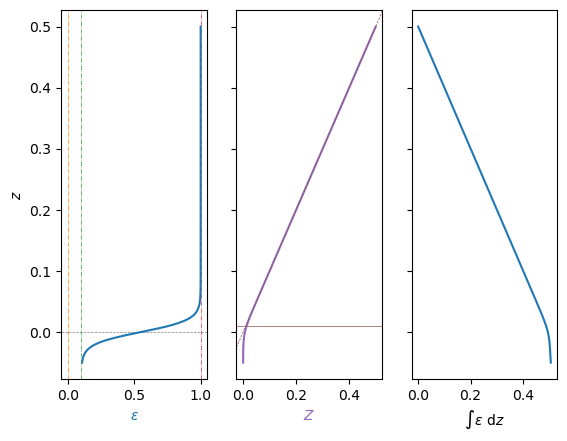

In [9]:
Z_LS_numerical = 1/2*(t + sympy.ln(sympy.cosh(a*t))/a)
Z_LS_numerical = Z_LS_numerical - Z_LS_numerical.subs(dict(t=t_b))
e_numerical = (1-e_b)*Z_LS_numerical.diff(t) + e_b
e_integral = e_b*t + (1-e_b)/2 * (t + 1/a * sympy.log(sympy.cosh(a*t)))
e_integral = - e_integral + e_integral.subs({t: h})

display(sympy.Equality(Z_LS, Z_LS_numerical))
display(sympy.Equality(e, e_numerical))
display(sympy.Equality(dynamicsymbols("E").diff(t), e_integral.diff(t)))
display(sympy.Equality(sympy.Symbol("E"), e_integral))
display(e_integral.diff(t).expand() + e_numerical.expand())

z_arr = np.linspace(-0.05, 0.5, num=1_000)
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, sharey=True)

ax1.axline((0, 0), slope=0, ls="--", c="gray", lw=0.5)
axlinestyle = dict(slope=np.inf, ls="-.", lw=0.5)
ax1.axline((0, 0), **axlinestyle, c="C1")
ax1.axline((constants[e_b], 0), **axlinestyle, c="C2")
ax1.axline((1, 0), **axlinestyle, c="C3")
ax1.plot(sympy.lambdify(t, e_numerical.subs(constants))(z_arr), z_arr, c="C0")
ax1.set_xlabel(r"$\epsilon$", color="C0")
ax1.set_ylabel("$z$")

ax2.plot(sympy.lambdify(t, Z_LS_numerical.subs(constants))(z_arr), z_arr, c="C4")
ax2.axline((0, 0), slope=1, ls="--", c="C5", lw=0.5)
ax2.axline((0, constants[d_p]), slope=0, ls="-", c="C5", lw=0.5)
ax2.set_xlabel("$Z$", color="C4")

ax3.plot(sympy.lambdify(t, e_integral.subs(constants))(z_arr), z_arr)
ax3.set_xlabel(r"$\int\epsilon~\mathrm{d}z$")

plt.show()

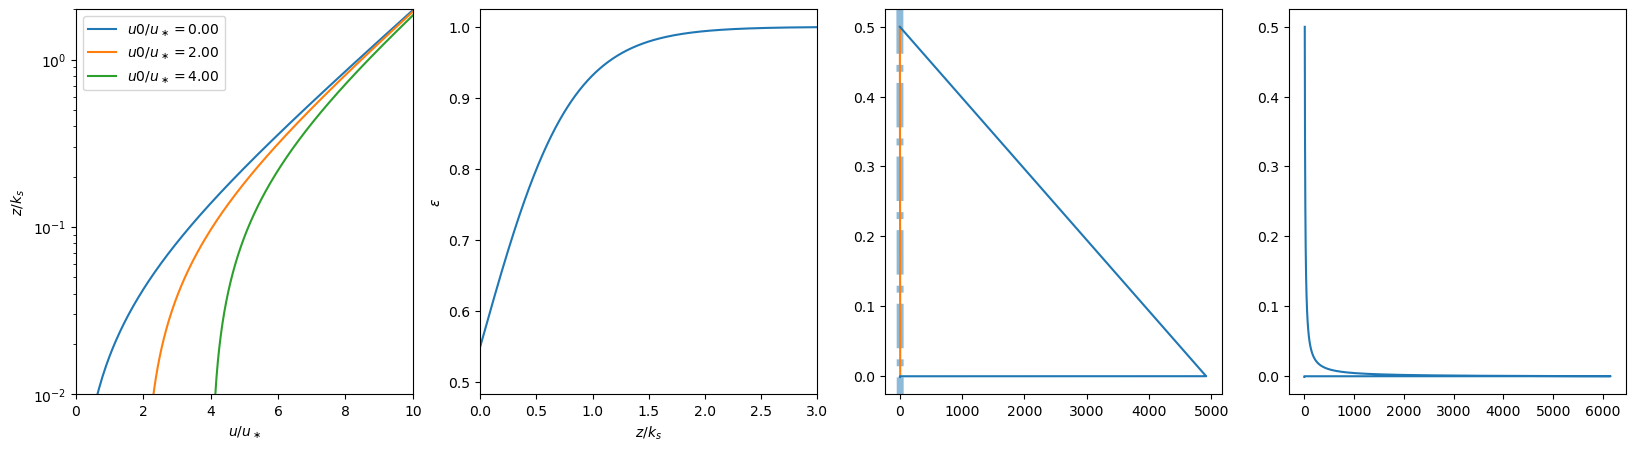

In [10]:
k_s = 2.5*constants[d_p]
u0 = 4.43

def lamb_profile(u0, h, ks=k_s, i=constants[i], kappa=constants[kappa], rho=constants[rho], g=constants[g], num=20_000):
    u_shear = (rho*g*h*i)**0.5
    zmin = -ks/30 * np.exp(kappa*u0/u_shear) + 1e-10
    z = np.linspace(zmin, h, num=num)
    return z, ks, u_shear, np.maximum(0, u0 + u_shear/kappa * np.log(1 + 30*z/ks * np.exp(-kappa*u0/u_shear)))

z_arr0, ks_lamb0, u_shear0, u_lamb0 = lamb_profile(0, constants[h])
z_arr, ks_lamb, u_shear, u_lamb = lamb_profile(u0, constants[h])
z_arr1, ks_lamb1, u_shear1, u_lamb1 = lamb_profile(2*u0, constants[h])

du_lamb = np.pad((u_lamb[2:] - u_lamb[:-2]) / (z_arr[2:]-z_arr[:-2]), (1, 1), mode="edge")

alpha_1 = kappa/30 * sympy.exp(kappa * u0/u_shear)
L = kappa*t + alpha_1*k_s
varepsilon = u_shear * (1-t/h) * L
tau_lamb_expr = rho * varepsilon * du
tau_lamb = sympy.lambdify([t, du, u], tau_lamb_expr.subs(constants))(z_arr, du_lamb, u_lamb)

G = rho*g*i*e_integral

fig, axes = plt.subplots(ncols=4, figsize=(20, 5))

axes[0].plot(u_lamb0/u_shear0, z_arr0/ks_lamb0, label=rf"$u0/u_\ast = {0:.2f}$")
axes[0].plot(u_lamb/u_shear, z_arr/ks_lamb, label=rf"$u0/u_\ast = {u0/u_shear:.2f}$")
axes[0].plot(u_lamb1/u_shear1, z_arr1/ks_lamb1, label=rf"$u0/u_\ast = {2*u0/u_shear1:.2f}$")
axes[0].semilogy()
axes[0].set_xlim(0, 10)
axes[0].set_ylim(1e-2, 2e0)
axes[0].set_xlabel(r"$u/u_\ast$")
axes[0].set_ylabel(r"$z/k_s$")
axes[0].legend()

axes[1].plot(z_arr/ks_lamb, sympy.lambdify(t, e_numerical.subs(constants))(z_arr))
axes[1].set_xlim(0, 3)
axes[1].set_ylabel(r"$\epsilon$")
axes[1].set_xlabel(r"$z/k_s$")

axes[2].axline((0, constants[h]), slope=-1/float((rho*g*i).subs(constants)), ls="-.", lw=5, alpha=0.5, c="C0")
axes[2].plot(sympy.lambdify(t, G.subs(constants))(z_arr), z_arr, c="C1")
axes[2].plot(tau_lamb, z_arr)

axes[3].plot(du_lamb, z_arr)

plt.show()

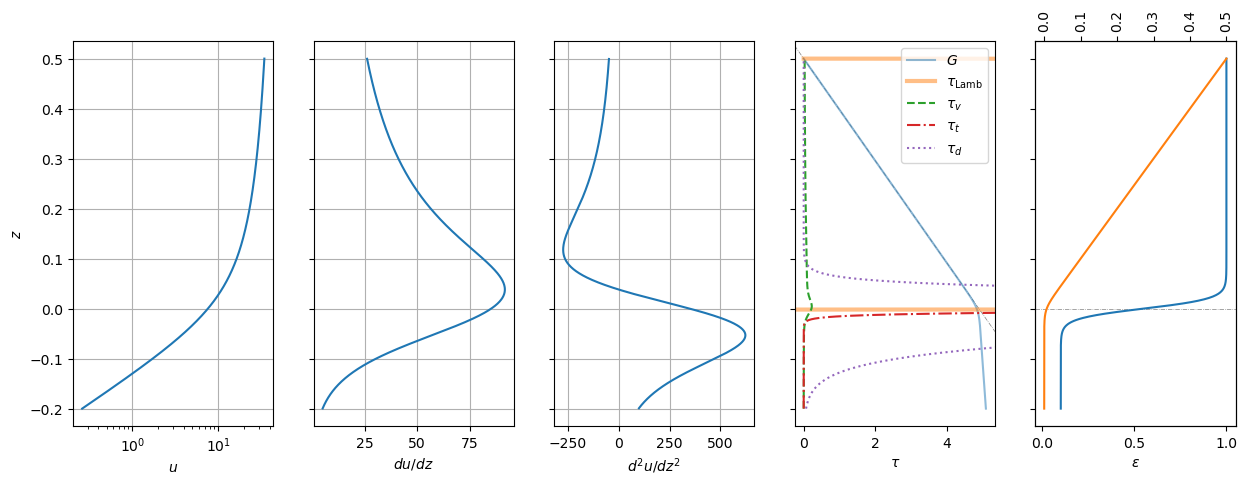

In [11]:
%matplotlib inline

def custom_profile(u_0, u_s, h, z_arr, alpha=10, gamma=1):
    beta = (u_s/u_0 - 1) / np.log(1+gamma*np.log(1+np.exp(alpha*h/h)))
    return u_0 * (1 + beta*np.log(1+gamma*np.log(1+np.exp(alpha*z_arr/h))))

z_arr = np.linspace(-0.2, 0.5, num=1_000)
u_custom = custom_profile(u_SSL_val, u_lamb0.max(), z_arr.max(), z_arr)  # TODO La vitesse en surface (du_dx) paraît beaucoup trop élevée !!

du_custom = np.pad(np.diff(u_custom) / np.diff(z_arr), (1, 0), mode="edge")
du_custom = np.pad((u_custom[2:] - u_custom[:-2]) / (z_arr[2:]-z_arr[:-2]), (1, 1), mode="edge")

fig, axes = plt.subplots(ncols=5, figsize=(15, 5), sharey=True)

axes[0].plot(u_custom, z_arr)
axes[0].semilogx()
axes[0].set_xlabel("$u$")
axes[0].set_ylabel("$z$")
axes[0].grid()

axes[1].plot(np.diff(u_custom)/np.diff(z_arr), (z_arr[1:]+z_arr[:-1])/2)
axes[1].set_xlabel("$du/dz$")
axes[1].grid()

axes[2].plot(np.diff(np.diff(u_custom)/np.diff(z_arr))/np.diff((z_arr[1:]+z_arr[:-1])/2), z_arr[1:-1])
axes[2].set_xlabel("$d^2u/dz^2$")
axes[2].grid()

tau_lamb = sympy.lambdify([t, du, u], tau_lamb_expr.subs(constants))(z_arr, du_custom, u_custom)

tau_v = sympy.lambdify([t, du, u], tau_v_func.subs({e: e_numerical} | constants).doit())(z_arr, du_custom, u_custom)
tau_t = sympy.lambdify([t, du, u], tau_t_func.subs({Z_LS: Z_LS_numerical, e: e_numerical} | constants).doit())(z_arr, du_custom, u_custom)
tau_d = sympy.lambdify([t, du, u], tau_d_func.subs({e: e_numerical} | constants).doit())(z_arr, du_custom, u_custom)

dG = sympy.lambdify(t, (e*rho*g*i).subs(constants|{e: e_numerical}))(z_arr)

axes[3].axline((0, constants[h]), slope=-1/float((rho*g*i).subs(constants)), ls="-.", alpha=0.5, lw=0.5, c="k")
axes[3].plot(sympy.lambdify(t, G.subs(constants))(z_arr), z_arr, label=r"$G$", alpha=0.5)
xlim = axes[3].get_xlim()
axes[3].plot(tau_lamb, z_arr, label=r"$\tau_\mathrm{Lamb}$", ls="-", alpha=0.5, lw=3)
axes[3].plot(tau_v, z_arr, label=r"$\tau_v$", ls="--")
axes[3].plot(tau_t, z_arr, label=r"$\tau_t$", ls="-.")
axes[3].plot(tau_d, z_arr, label=r"$\tau_d$", ls=":")
axes[3].set_xlim(xlim)
axes[3].set_xlabel(r"$\tau$")
axes[3].legend()

axes[4].axline((constants[d_p], 0), slope=0, ls="-.", alpha=0.5, c="k", lw=0.5)
axes[4].plot(sympy.lambdify(t, e_numerical.subs(constants))(z_arr), z_arr)
axes[4].set_xlabel(r"$\epsilon$")

ax_Z_LS = axes[4].twiny()
ax_Z_LS.set_xticks(axes[0].get_yticks(), axes[0].get_yticklabels(), rotation=90)
ax_Z_LS.plot(sympy.lambdify(t, Z_LS_numerical.subs(constants))(z_arr), z_arr, c="C1")

plt.show()

u_SSL_val = 6.728395061728397e-05
[0.         0.         0.         0.         0.         0.68025876
 4.62104945 5.30678492 5.7097672  5.99620554]


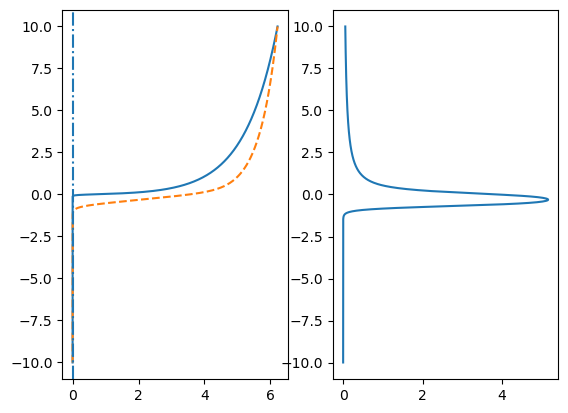

In [12]:
def custom_profile(u_0, u_s, h, z_arr):
    alpha = np.log(np.exp(np.exp(u_s/u_0-1)-1)-1) / h
    print(f"{alpha = }")
    return u_0 * (1 + np.log(1+np.log(1+np.exp(z_arr*alpha))))

def custom_profile(u_0, u_s, h, z_arr, alpha=100, gamma=1_000):
    beta = (u_s/u_0 - 1) / np.log(1+gamma*np.log(1+np.exp(alpha*h/h)))
    return u_0 * (1 + beta*np.log(1+gamma*np.log(1+np.exp(alpha*z_arr/h))))

alpha = 50
print(f"{u_SSL_val = }")
_x = np.linspace(-10, 10, num=1_000)
_u = np.log(1 + np.log(1+np.exp(_x*alpha)))
__u = custom_profile(u_SSL_val, _u.max(), _x.max(), _x)
print(_u[::100])

fig, axes = plt.subplots(ncols=2)

axes[0].plot(_u, _x)
axes[0].plot(__u, _x,'--')
axes[0].axline((u_SSL_val, 0), slope=np.inf, ls="-.")

axes[1].plot(np.diff(__u)/np.diff(_x), (_x[1:]+_x[:-1])/2)

plt.show()

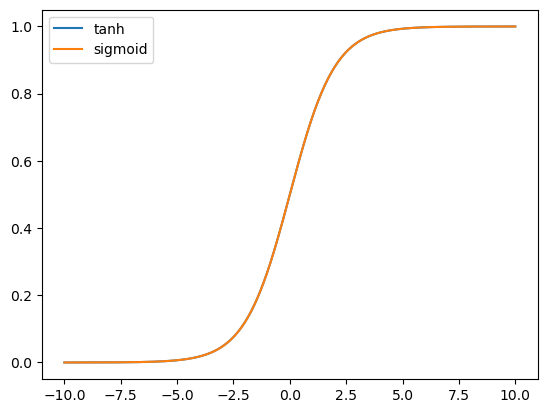

In [13]:
plt.plot(_x, np.tanh(_x/2)/2+0.5, label="tanh")
plt.plot(_x, 1/(1+np.exp(-_x)), label="sigmoid")
plt.legend()
plt.show()